# TorchRL DQN

In this tutorial, we will learn how to use DQN

This notebook was modified from the official tutorials provided by torchRL: 

**Get started with TorchRL's modules**
Author: `Vincent Moens <https://github.com/vmoens>`
url: https://docs.pytorch.org/rl/stable/tutorials/getting-started-3.html

### Install TorchRL

First let's install torchrl and tensordict.


In [1]:
#!pip install tensordict
#!pip install torchrl

In [64]:
from tensordict.nn import TensorDictSequential
from torchrl.modules import EGreedyModule

import torch
from tensordict.nn import TensorDictModule
from tensordict import TensorDict
from torchrl.envs import GymEnv
from torch import nn

from torchrl.envs.utils import ExplorationType, set_exploration_type
from torchrl.modules import QValueActor
from torch.optim import Adam
from torchrl.modules import QValueActor
from torchrl.objectives import DQNLoss


### Data collectors

In the last tutorial we started to allow our agents to learn. We learned how to implemented a DQN algorithm and how it works internally. 

But we haven't shown how we can do this repeadely through time, with many agent-enviornment interactions. Let's learn how to collect and use this data, and handle interactions between agents and their environment.

To do this we will learn about *DataCollectors*

The primary data collector discussed here is the SyncDataCollector, which is the focus of this documentation. At a fundamental level, a collector is a straightforward class responsible for executing your policy within the environment, resetting the environment when necessary, and providing batches of data of a predefined size. Unlike the rollout() method demonstrated in the earlier tutorials, collectors do not reset between consecutive batches of data. Consequently, two successive batches of data may contain elements from the same trajectory.

The basic arguments you need to pass to your collector are:

* the size of the batches you want to collect (frames_per_batch), 
* the length (possibly infinite) of the iterator, 
* the policy and the environment. 

For simplicity, we will use a dummy, random policy in this example.

In [65]:
import torch

from torchrl.collectors import SyncDataCollector
from torchrl.envs import GymEnv
from torchrl.modules import RandomPolicy

torch.manual_seed(0)

env = GymEnv("CartPole-v1")
env.set_seed(0)

policy = RandomPolicy(env.action_spec)
collector = SyncDataCollector(env, policy, frames_per_batch=200, total_frames=-1)

/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


We now expect that our collector will deliver batches of size 200 no matter what happens during collection. In other words, we may have multiple trajectories in this batch! The total_frames indicates how long the collector should be. A value of -1 will produce a never ending collector.

Let’s iterate over the collector to get a sense of what this data looks like:

In [66]:
for data in collector:
    print(data)
    break

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([200, 2]), device=cpu, dtype=torch.int64, is_shared=False),
        collector: TensorDict(
            fields={
                traj_ids: Tensor(shape=torch.Size([200]), device=cpu, dtype=torch.int64, is_shared=False)},
            batch_size=torch.Size([200]),
            device=None,
            is_shared=False),
        done: Tensor(shape=torch.Size([200, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([200, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([200, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([200, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([200, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor

As you can see, our data is augmented with some collector-specific metadata grouped in a "collector" sub-tensordict that we did not see during environment rollouts. This is useful to keep track of the trajectory ids. In the following list, each item marks the trajectory number the corresponding transition belongs to:

In [67]:
print(data["collector", "traj_ids"])


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9])


Because we are using the cartpole environment, each time the pole falls the environment is reset and we get another trajectory ID.

Data collectors are very useful when it comes to coding state-of-the-art algorithms, as performance is usually measured by the capability of a specific technique to solve a problem in a given number of interactions with the environment (the total_frames argument in the collector). For this reason, most training loops in our examples look like this:

```
for data in collector:
     # your algorithm here
```

### Replay buffers

Now that we have explored how to collect data, we would like to know how to store it. In RL, the typical setting is that the data is collected, stored temporarily and cleared after a little while given some heuristic: first-in first-out or other. A typical pseudo-code would look like this:

```
>>> for data in collector:
...     storage.store(data)
...     for i in range(n_optim):
...         sample = storage.sample()
...         loss_val = loss_fn(sample)
...         loss_val.backward()
...         optim.step() # etc

```

The parent class that stores the data in TorchRL is referred to as ReplayBuffer. TorchRL’s replay buffers are composable: you can edit the storage type, their sampling technique, the writing heuristic or the transforms applied to them. We will leave the fancy stuff for a dedicated in-depth tutorial. The generic replay buffer only needs to know what storage it has to use. In general, we recommend a TensorStorage subclass, which will work fine in most cases. We’ll be using LazyMemmapStorage in this tutorial, which enjoys two nice properties: first, being “lazy”, you don’t need to explicitly tell it what your data looks like in advance. Second, it uses MemoryMappedTensor as a backend to save your data on disk in an efficient way. The only thing you need to know is how big you want your buffer to be.

In [68]:
from torchrl.data.replay_buffers import LazyMemmapStorage, ReplayBuffer
import tempfile

buffer_scratch_dir = tempfile.TemporaryDirectory().name

buffer = ReplayBuffer(
    storage=LazyMemmapStorage(max_size=1000, scratch_dir=buffer_scratch_dir)
)

Populating the buffer can be done via the add() (single element) or extend() (multiple elements) methods. Using the data we just collected, we initialize and populate the buffer in one go:

In [69]:
indices = buffer.extend(data)

2026-03-05 12:50:40,782 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([1000]) shape [END]


We can check that the buffer now has the same number of elements as what we got from the collector:



In [70]:
assert len(buffer) == collector.frames_per_batch


The only thing left to know is how to gather data from the buffer. Naturally, this relies on the sample() method. Because we did not specify that sampling had to be done without repetitions, it is not guaranteed that the samples gathered from our buffer will be unique:

In [71]:
sample = buffer.sample(batch_size=30)
print(sample)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([30, 2]), device=cpu, dtype=torch.int64, is_shared=False),
        collector: TensorDict(
            fields={
                traj_ids: Tensor(shape=torch.Size([30]), device=cpu, dtype=torch.int64, is_shared=False)},
            batch_size=torch.Size([30]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Size([30, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([30, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([30, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([30, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([30, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=to

### DQN

Let's put this all together and try the collector and buffer out with the DQN algorithm we learnt in the last tutorial.

Let's define our policy 

In [72]:

env = GymEnv("CartPole-v1")


n_obs = env.observation_spec["observation"].shape[-1]
n_act = env.action_spec.shape[-1]
nodes = 16

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    nn.Linear(n_obs,nodes),
    nn.ReLU(),
    nn.Linear(nodes,nodes),
    nn.ReLU(),
    nn.Linear(nodes, n_act),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["observation"],
    out_keys=["action_value"],          
)

qvalue_actor = QValueActor(module=value_net, spec=env.action_spec)

#when collecting data sometimes use random (e-greedy)
exploration_module = EGreedyModule(
    spec=env.action_spec, 
    annealing_num_steps=1000, 
    eps_init=0.95
)
qvalue_actor_explore = TensorDictSequential(qvalue_actor, exploration_module)





Let's then define a loss function and an optimizer


In [73]:
dqn_loss = DQNLoss(qvalue_actor) #when updating use greedy (always choose best action)

optim = Adam(dqn_loss.parameters(), lr=0.0003)

Now let's write a loop that uses the collector and not one batch of data from a rollout

In [74]:

collector = SyncDataCollector(env, qvalue_actor_explore, frames_per_batch=200, total_frames=200000)

buffer_dqn = ReplayBuffer(
    storage=LazyMemmapStorage(max_size=10000)
)

loss_over_time = []

#agent-environment interactions!
#rollout = env.rollout(max_steps=10, policy=qvalue_actor_explore)
for data in collector:
    
    buffer_dqn.extend(data)
    sample = buffer_dqn.sample(batch_size=64)

    loss = dqn_loss(sample)
    loss_val = loss["loss"]

    #let's now optimize the model used to estimate q-values
    optim.zero_grad(set_to_none=True)
    loss_val.backward() #backprop!
    optim.step()

    #let's keep track of the loss over time
    loss_over_time.append(loss_val.item())


/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


2026-03-05 12:50:41,100 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([10000]) shape [END]


/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/objectives/common.py:40: UserWarning: No target network updater has been associated with this loss module, but target parameters have been found. While this is supported, it is expected that the target network updates will be manually performed. You can deactivate this warning by turning the RL_WARNINGS env variable to False.
  warnings.warn(
/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/objectives/common.py:457: UserWarning: No target network updater has been associated with this loss module, but target parameters have been found. While this is supported, it is expected that the target network updates will be manually performed. You can deactivate this warning by turning the RL_WARNINGS env variable to False.
  warnings.warn(


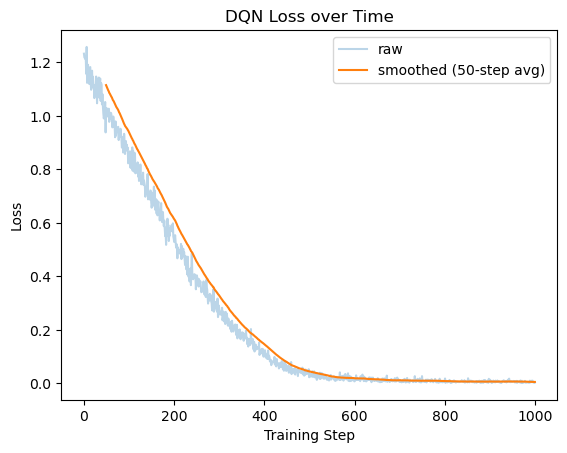

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

smoothed = pd.Series(loss_over_time).rolling(window=50).mean()

plt.plot(loss_over_time, alpha=0.3, label="raw")
plt.plot(smoothed, label="smoothed (50-step avg)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DQN Loss over Time")
plt.legend()
plt.show()

You should see a drop in loss over time. Remember this means that the agent is getting better at predicting the TD target (i.e., the reward it will recieve plus the discounted estimate of the value of the next state-action). So it's learning how it's actions lead to rewards and more valuable states.

### Target network

In [ ]:
from torchrl.objectives import SoftUpdate


dqn_loss = DQNLoss(
    value_network=qvalue_actor,
    action_space=env.action_spec,
    delay_value=True,          # create a target network (slowly updates)
)

updater = SoftUpdate(dqn_loss, eps=0.99)  # small tau = slow target update


optim = Adam(dqn_loss.parameters(), lr=0.0003)

In [77]:

collector = SyncDataCollector(env, qvalue_actor_explore, frames_per_batch=200, total_frames=200000)

buffer_dqn = ReplayBuffer(
    storage=LazyMemmapStorage(max_size=10000)
)

loss_over_time = []

#agent-environment interactions!
#rollout = env.rollout(max_steps=10, policy=qvalue_actor_explore)
for data in collector:
    
    buffer_dqn.extend(data)
    sample = buffer_dqn.sample(batch_size=64)

    loss = dqn_loss(sample)
    loss_val = loss["loss"]

    #let's now optimize the model used to estimate q-values
    optim.zero_grad(set_to_none=True) #make sure everything gets set to zero before backprob..
    loss_val.backward() #backprop!
    optim.step()
    updater.step() #now updates the target network as well


    #let's keep track of the loss over time
    loss_over_time.append(loss_val.item())




2026-03-05 12:54:02,206 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([10000]) shape [END]


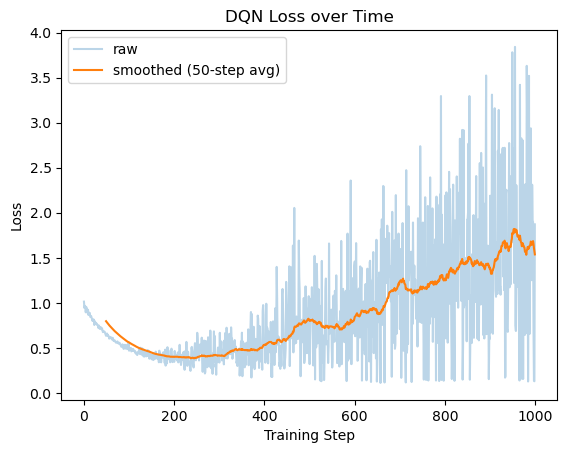

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

smoothed = pd.Series(loss_over_time).rolling(window=50).mean()

plt.plot(loss_over_time, alpha=0.3, label="raw")
plt.plot(smoothed, label="smoothed (50-step avg)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DQN Loss over Time")
plt.legend()
plt.show()

You should see that the addition of the target network along with the policy network helps with calculating the loss. (not yet!)



Now we know how to use data collectors and replay buffers to feed our algorithm agent-environment inteactions! 

Let's see some better ways to log and visualize our progress!

### End

**things to try**

* Learn more about [replay buffers](https://docs.pytorch.org/rl/stable/tutorials/rb_tutorial.html#rb-tuto)
* Learn more about [collectors](https://docs.pytorch.org/rl/stable/reference/collectors_basics.html#ref-collectors) 